PHASE 1 — Google Colab + Dataset Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Copy of Year 2025 Tracker for English Learning.gsheet', '347a2e72-ca18-43ca-9364-d344b3cc2c79 (3).pdf', '347a2e72-ca18-43ca-9364-d344b3cc2c79 (2).pdf', '347a2e72-ca18-43ca-9364-d344b3cc2c79 (1).pdf', "Jyesta Corporate Entity Group Discussion Schedule (31-Oct-2025)-DEC'26.xlsx", '347a2e72-ca18-43ca-9364-d344b3cc2c79.pdf', '5f558e65-2021-454f-b46f-c7f7b7ebede2 (1).pdf', '5f558e65-2021-454f-b46f-c7f7b7ebede2.pdf', 'Fake.csv', 'True.csv']


In [3]:
files = os.listdir('/content/drive/MyDrive')
csv_files = [f for f in files if f.lower().endswith('.csv')]
print(csv_files)

['Fake.csv', 'True.csv']


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PHASE 2 — Load and Understand the Data

In [9]:
#load the data
fake_df = pd.read_csv('/content/drive/MyDrive/Fake.csv')
true_df = pd.read_csv('/content/drive/MyDrive/True.csv')

print("Fake shape:", fake_df.shape)
print("True shape:", true_df.shape)

Fake shape: (23481, 4)
True shape: (21417, 4)


In [6]:
#Columns, dtypes, and a peek at the data
print("Columns:", fake_df.columns.tolist())
print()
print(fake_df.dtypes)
print()
fake_df.head()

Columns: ['title', 'text', 'subject', 'date']

title      object
text       object
subject    object
date       object
dtype: object



,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [7]:
#Missing values and duplicates
print("Fake missing values:\n", fake_df.isnull().sum())
print()
print("True missing values:\n", true_df.isnull().sum())
print()
print("Fake duplicates:", fake_df.duplicated().sum())
print("True duplicates:", true_df.duplicated().sum())

Fake missing values:
 title      0
text       0
subject    0
date       0
dtype: int64

True missing values:
 title      0
text       0
subject    0
date       0
dtype: int64

Fake duplicates: 3
True duplicates: 206


In [8]:
#Subject and date distribution
print("Fake subjects:\n", fake_df['subject'].value_counts())
print()
print("True subjects:\n", true_df['subject'].value_counts())

Fake subjects:
 subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64

True subjects:
 subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64


PHASE 3 — Create the Classification Dataset

In [10]:
#Labels and combination
fake_df['label'] = 0  # Fake
true_df['label'] = 1  # Real

df = pd.concat([fake_df, true_df], axis=0, ignore_index=True)
df['content'] = df['title'] + " " + df['text']

print(df.shape)
df[['content', 'label']].sample(5)

(44898, 6)


,content,label
7422,Fox News Declares All-Out War On The ‘Sick’ M...,0
18408,BROKE City of Chicago Spends Taxpayer Money St...,0
5314,Former George W. Bush Attorney Jumps Ship Fro...,0
21076,FLASHBACK: BERNIE SANDERS’ Socialist Democrat ...,0
7430,Republican Lawmakers Helped Orchestrate The B...,0


PHASE 4 — Data Cleaning + EDA

In [11]:
#Remove duplicates
print("Before dedup:", df.shape)

df = df.drop_duplicates(subset='content').reset_index(drop=True)

print("After dedup:", df.shape)
print(df['label'].value_counts())

Before dedup: (44898, 6)
After dedup: (39105, 6)
label
1    21197
0    17908
Name: count, dtype: int64


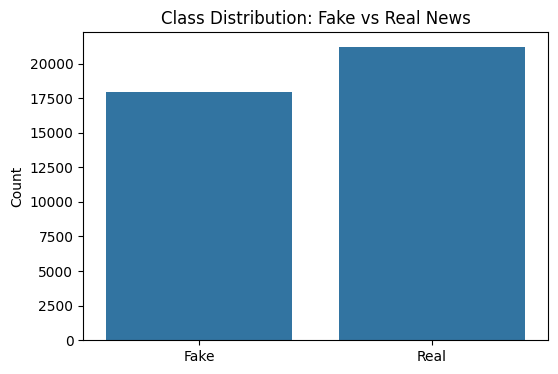

In [12]:
#Class distribution plot
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.xticks([0, 1], ['Fake', 'Real'])
plt.title('Class Distribution: Fake vs Real News')
plt.xlabel('')
plt.ylabel('Count')
plt.show()

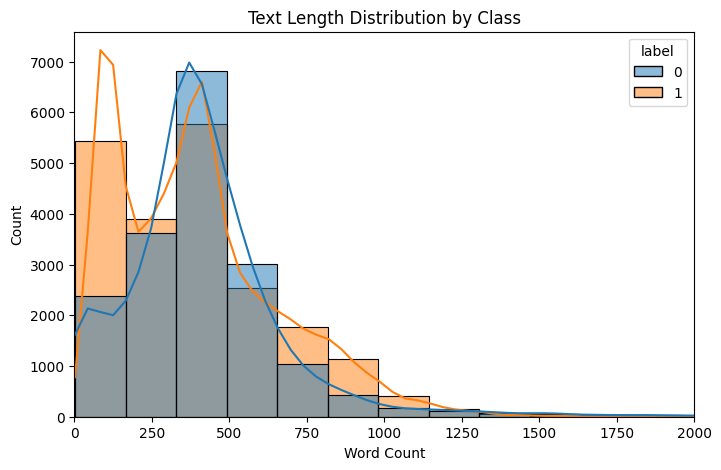

         count        mean         std  min    25%    50%    75%     max
label                                                                   
0      17908.0  429.015077  357.153684  2.0  279.0  385.0  514.0  8148.0
1      21197.0  394.814644  273.772755  4.0  157.0  368.0  533.0  5181.0


In [13]:
#Text length analysis
df['text_length'] = df['content'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='text_length', hue='label', bins=50, kde=True)
plt.title('Text Length Distribution by Class')
plt.xlabel('Word Count')
plt.xlim(0, 2000)  # zoom in, since a few very long articles can skew the view
plt.show()

print(df.groupby('label')['text_length'].describe())

In [14]:
#Inspect and remove near-empty articles
# Look at the shortest ones
print(df[df['text_length'] < 10][['content', 'label', 'text_length']])

                                                 content  label  text_length
9358   https://100percentfedup.com/served-roy-moore-v...      0            2
11116  MY FAVORITE EXCUSES…Featuring Hillary Rotten C...      0            8
11557  SENATOR PUSHES To Remove Clinton’s Name From A...      0            9
11780  IT’S NOT A “MUSLIM BAN” You Big Dummies! [VIDE...      0            9
11852                    LIVE FEED: INAUGURATION 2017!        0            4
11873      BEST TWEET OF THE WEEK: “Hillary For Sale!”        0            8
11898           WATCH Life Accordion To Trump! [VIDEO]        0            6
11904  YES! JUDGE JEANINE HAMMERS Hollywood Lefty Ros...      0            9
11955  SICKENING! MTV HOST MOCKS Senator Jeff Session...      0            9
12024        YES, OBAMA…There Is A Magic Wand! [Video]        0            7
12036    WHERE’S HILLARY? CLINTON SPOTTED Dining Alone        0            6
12053   TWEET OF THE DAY: Hillary…The Price Of Failure        0            8

In [15]:
#Drop only genuinely broken rows (URL-as-content)# Genuine junk: content that is just a URL, no real text
junk_mask = df['content'].str.strip().str.startswith('http')
print("Junk rows found:", junk_mask.sum())
print(df[junk_mask][['content', 'label']])

df = df[~junk_mask].reset_index(drop=True)
print("Shape after removing junk:", df.shape)


Junk rows found: 5
                                                 content  label
9358   https://100percentfedup.com/served-roy-moore-v...      0
15504  https://100percentfedup.com/video-hillary-aske...      0
15505  https://100percentfedup.com/12-yr-old-black-co...      0
15836  https://fedup.wpengine.com/wp-content/uploads/...      0
15837  https://fedup.wpengine.com/wp-content/uploads/...      0
Shape after removing junk: (39100, 7)


PHASE 5 — Text Preprocessing

In [16]:
#Build and apply the cleaning function
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)          # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()      # remove extra whitespace
    return text

df['clean_content'] = df['content'].apply(clean_text)

df[['content', 'clean_content']].sample(3)

,content,clean_content
26930,Trump says U.S. should mull more racial profil...,trump says us should mull more racial profilin...
8909,Marco Rubio Panders To Israel By Insulting Pr...,marco rubio panders to israel by insulting pre...
36085,Death toll in Puerto Rico from Hurricane Maria...,death toll in puerto rico from hurricane maria...


In [17]:
#Remove stopwords
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])

df['clean_content'] = df['clean_content'].apply(remove_stopwords)

df[['content', 'clean_content']].sample(3)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,content,clean_content
36000,Catalan leader backs mediation to resolve regi...,catalan leader backs mediation resolve regiona...
37462,U.S. and Iran argue over inspections at nuclea...,us iran argue inspections nuclear watchdog mee...
23206,EU welcomes Pence assurance of Trump's support...,eu welcomes pence assurance trumps support bru...


PHASE 6 — Train/Test Split

In [18]:
from sklearn.model_selection import train_test_split

X = df['clean_content']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("Train label distribution:\n", y_train.value_counts(normalize=True))
print("Test label distribution:\n", y_test.value_counts(normalize=True))

Train size: 31280
Test size: 7820
Train label distribution:
 label
1    0.542136
0    0.457864
Name: proportion, dtype: float64
Test label distribution:
 label
1    0.542072
0    0.457928
Name: proportion, dtype: float64


PHASE 7 — TF-IDF

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,1))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (31280, 5000)
Test TF-IDF shape: (7820, 5000)


PHASE 8 — Logistic Regression

In [22]:
#Train and predict
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression trained.")

Logistic Regression trained.


In [23]:
#Evaluate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))
print()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print()
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy: 0.9874680306905371
Precision: 0.9834228344618258
Recall: 0.9936305732484076
F1-score: 0.9885003520300399

Confusion Matrix:
 [[3510   71]
 [  27 4212]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      3581
           1       0.98      0.99      0.99      4239

    accuracy                           0.99      7820
   macro avg       0.99      0.99      0.99      7820
weighted avg       0.99      0.99      0.99      7820



PHASE 9 — Naive Bayes

In [24]:
#Train and predict
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes trained.")

Naive Bayes trained.


In [25]:
#Evaluateprint("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1-score:", f1_score(y_test, y_pred_nb))
print()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print()
print("Classification Report:\n", classification_report(y_test, y_pred_nb))


Precision: 0.9438414346389806
Recall: 0.9436187780136824
F1-score: 0.9437300931933467

Confusion Matrix:
 [[3343  238]
 [ 239 4000]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      3581
           1       0.94      0.94      0.94      4239

    accuracy                           0.94      7820
   macro avg       0.94      0.94      0.94      7820
weighted avg       0.94      0.94      0.94      7820



PHASE 10 — Model Comparison

In [27]:
#Comparison table
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Multinomial Naive Bayes'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_nb)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_nb)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_nb)],
    'F1-score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_nb)]
})

print(comparison)


                     Model  Accuracy  Precision    Recall  F1-score
0      Logistic Regression  0.987468   0.983423  0.993631   0.98850
1  Multinomial Naive Bayes  0.939003   0.943841  0.943619   0.94373


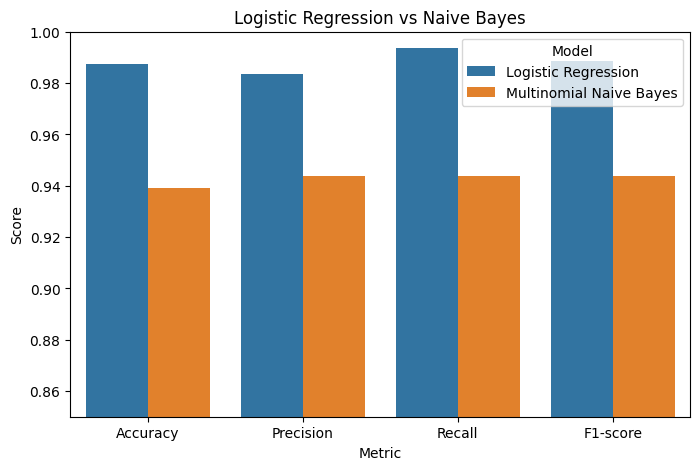

In [28]:
#Visualization
comparison_melted = comparison.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(8,5))
sns.barplot(data=comparison_melted, x='Metric', y='Score', hue='Model')
plt.title('Logistic Regression vs Naive Bayes')
plt.ylim(0.85, 1.0)
plt.show()

PHASE 11 — Error Analysis

In [29]:
#Pull out example predictions
# Build a results dataframe aligned with the test set
results_df = pd.DataFrame({
    'text': X_test.values,
    'actual': y_test.values,
    'predicted': y_pred_lr
})

# Correctly classified
correct_fake = results_df[(results_df['actual'] == 0) & (results_df['predicted'] == 0)]
correct_real = results_df[(results_df['actual'] == 1) & (results_df['predicted'] == 1)]

# Incorrectly classified
wrong_fake = results_df[(results_df['actual'] == 0) & (results_df['predicted'] == 1)]  # Fake predicted as Real
wrong_real = results_df[(results_df['actual'] == 1) & (results_df['predicted'] == 0)]  # Real predicted as Fake

print("Correctly classified Fake (sample):")
print(correct_fake['text'].sample(2).values)
print()
print("Correctly classified Real (sample):")
print(correct_real['text'].sample(2).values)
print()
print("Incorrectly classified — Fake predicted as Real:")
print(wrong_fake['text'].sample(min(3, len(wrong_fake))).values)
print()
print("Incorrectly classified — Real predicted as Fake:")
print(wrong_real['text'].sample(min(3, len(wrong_real))).values)

Correctly classified Fake (sample):
['obamas lawsuit nc really jackboot government americas throats obama clearly attempting strip americans right express opinions social issues based religion morals americans found scary place remaining silent know speaking afraid shamed progressive left meanwhile left continues blur lines morality hoping erase individual thought speechin communist society individual best interests indistinguishable society best interest thus idea individual freedom incompatible communist ideology reason hold individual speech information rights would better society us care little debate public bathrooms however care ongoing destruction federalism individual choice goodfaith debateone reliable way quash dissent force moral codes others liken cause civil rights fight every liberal issue situated somewhere great historical arc equality justice person stands even one causes great increasingly trivial according cultural imperialists obama administration aligned klan liter

PHASE 12 — Custom News Prediction

In [30]:
def predict_news(text):
    cleaned = clean_text(text)
    cleaned = remove_stopwords(cleaned)
    vectorized = tfidf.transform([cleaned])
    prediction = lr_model.predict(vectorized)[0]
    probability = lr_model.predict_proba(vectorized)[0]

    label = "Real" if prediction == 1 else "Fake"
    confidence = probability[prediction]

    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.2%}")

# Try it with a sample
predict_news("Scientists announce breakthrough in renewable energy storage technology")

Prediction: Fake
Confidence: 55.89%


In [31]:
predict_news("Senate committee to review new infrastructure spending bill next week")
predict_news("BREAKING: Government Secretly Planning to Ban All Cash Transactions by 2027")

Prediction: Real
Confidence: 81.81%
Prediction: Fake
Confidence: 87.00%


PHASE 13 — Save the Model

In [32]:
import joblib

joblib.dump(tfidf, '/content/drive/MyDrive/tfidf_vectorizer.pkl')
joblib.dump(lr_model, '/content/drive/MyDrive/logistic_regression_model.pkl')

print("Model and vectorizer saved.")

Model and vectorizer saved.


In [33]:
#Confirm loading works
loaded_tfidf = joblib.load('/content/drive/MyDrive/tfidf_vectorizer.pkl')
loaded_model = joblib.load('/content/drive/MyDrive/logistic_regression_model.pkl')

test_pred = loaded_model.predict(loaded_tfidf.transform(["Senate committee to review new infrastructure spending bill"]))
print("Loaded model prediction:", "Real" if test_pred[0] == 1 else "Fake")

Loaded model prediction: Real
